![Imgur](https://i.imgur.com/h4PPC71.png)
#**18-modul. Amaliyot. Customer Churn**
# 18.6. Modul boʻyicha yakuniy amaliy vazifa

**Bu vazifa orqali data sayns jarayoni:**

✔️ maʼlumot tayyorlash;

  ✔️ model qurish;

  ✔️ baholash;

  ✔️ natijalarni tahlil qilish
  kabi koʻnikmalarga ega boʻlasiz.

#**Vazifa: bank mijozlarining noroziligini bashorat qilish**

**Vazifa tavsifi**

Sizga bank mijozlari haqida maʼlumotlar toʻplami berilgan. Maqsad – qaysi mijozlar bank xizmatlaridan voz kechishini (churn) oldindan bashorat qilish. Bank bu orqali oʻz mijozlarini ushlab qolish strategiyalarini yaxshilashi mumkin.

**Maʼlumotlar toʻplami**

Kaggle platformasidagi Churn Modelling maʼlumotlar toʻplamidan foydalanamiz. Ushbu toʻplamda 10 000 ta mijozning quyidagi maʼlumotlari mavjud:

- mijoz identifikatori (RowNumber, CustomerId, Surname);
- geografik joylashuvi (Geography);
- jinsi (Gender);
- yoshi (Age);
- kredit balli (CreditScore);
- yillik daromadi (EstimatedSalary);
- bankda qancha vaqtdan beri mijoz ekani (Tenure);
- qancha mahsulotdan foydalanishi (NumOfProducts);
- faoliyati (HasCrCard, IsActiveMember);
- balans (Balance);
- prognoz qilish holati, churn (Exited) – maqsadli oʻzgaruvchi.

**Topshiriqlar**

1. **Maʼlumotlarni tahlil qilish va tozalash:**
   - Maʼlumotlardagi boʻsh qiymatlar va anomaliyalarni aniqlang hamda tozalang.
   - Kategorik oʻzgaruvchilarni raqamli koʻrinishga oʻtkazing (masalan, one-hot encoding yordamida).

2. **Maʼlumotlarni boʻlish:**
   - Maʼlumotlarni training va test toʻplamlariga ajrating (masalan, 80% training, 20% test).

3. **Model qurish:**
   - Quyidagi algoritmlar yordamida modellarni yarating:
     - Logistic Regression
     - Support Vector Machine (SVM)
     - Decision Tree
     - Random Forest
     - XGBoost

4. **Modellarni baholash:**
   - Har bir model uchun quyidagi koʻrsatkichlarni hisoblang:
     - Aniqlik (Accuracy)
     - Toʻgʻrilik (Precision)
     - Recall
     - F1-score

5. **Natijalarni tahlil qilish:**
   - Olingan natijalarni solishtiring va qaysi model eng yaxshi ishlashini aniqlang.
   - Eng yaxshi model asosida bankka mijozlarni ushlab qolish boʻyicha tavsiyalar bering.
---

###*** ESLATMA**. *Ushbu amaliy vazifada siz oʻtmagan mavzulardan ham savollar va vazifalar boʻlishi mumkin! Bu savollarni mustaqil oʻrganishingiz kerak boʻladi. Bunday vazifalar mustaqil izlanish koʻnikmangizni oshirish uchun tayyorlandi!*

In [175]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [176]:
# Javobni shu yerda yozing.
url = "https://raw.githubusercontent.com/dilshod12352005/data1/refs/heads/main/Churn_Modelling.csv"
df = pd.read_csv(url, index_col='RowNumber')
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


# Datasetimizda NAN qiymatlar yo'q ekan

In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.1+ MB


# Bankda Qolgan va ketgan foydalanuvchilar soni

In [178]:
churn=df['Exited'].value_counts()
churn

,count
Exited,
0,7963
1,2037


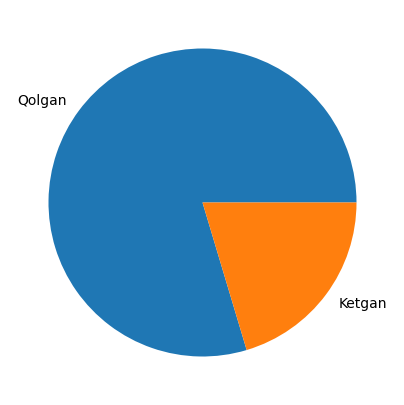

In [179]:
plt.figure(figsize=(5,5))
plt.pie(churn, labels=['Qolgan','Ketgan'])
plt.show()

# Model qurishimiz uchun umuman tasiri yo'q ustunlarni chiqarib tashlaymiz

In [180]:
df.drop(['CustomerId','Surname'], axis=1, inplace=True)

In [181]:
df


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,
1,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9996,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9997,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9998,709,France,Female,36,7,0.00,1,0,1,42085.58,1


Matinli ustunlarni raqamga keltirishimiz kerak , shu ustunlarni ajratib olamiz

In [182]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [183]:
df["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


Joylashuv ustunini songa o'tqazib oldik OneHotEncoder orqali

In [184]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False)
gegraphy_arr=ohe.fit_transform(df[['Geography']])
gegraphy_arr

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

Jins ustunini 0 yoki 1 ga o'tqazdik

In [185]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Gender']=le.fit_transform(df['Gender'])


In [186]:
df["Gender"].value_counts()

,count
Gender,
1,5457
0,4543


Gegraphy_arr masivni DataFrame ga o'tqasib df ga qo'shamiz

In [187]:
# columns qismiga ['Geography'] ni qo'shish
gegraphy_df = pd.DataFrame(gegraghy_arr,
                           columns=ohe.get_feature_names_out(['Geography']),
                           index=df.index)
df = pd.concat([df.drop('Geography', axis=1), gegraphy_df], axis=1)
print(df.isnull().sum().sum())
df.head()

0


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
RowNumber,,,,,,,,,,,,,
1,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
2,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
3,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
4,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
5,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [188]:
df.corrwith(df['Exited']).abs().sort_values(ascending=False)

,0
Exited,1.000000
Age,0.285323
Geography_Germany,0.173488
IsActiveMember,0.156128
Balance,0.118533
Gender,0.106512
Geography_France,0.104955
Geography_Spain,0.052667
NumOfProducts,0.047820
CreditScore,0.027094


Train va test

In [189]:
X=df.drop('Exited', axis=1)
y=df['Exited']

In [190]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2,stratify=y  ,random_state=12)

In [191]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [192]:
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Logistic Regression

              precision    recall  f1-score   support

           0       0.82      0.96      0.88      1593
           1       0.53      0.19      0.28       407

    accuracy                           0.80      2000
   macro avg       0.67      0.57      0.58      2000
weighted avg       0.76      0.80      0.76      2000

Model aniqligi : 0.8005


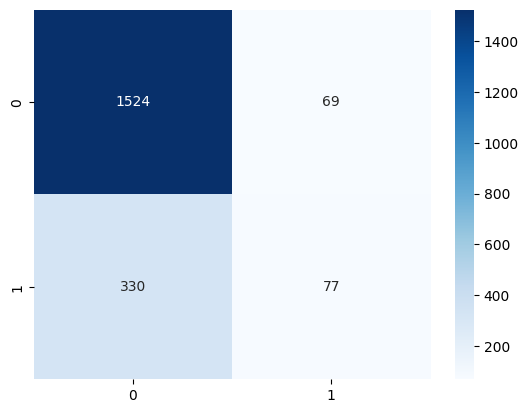

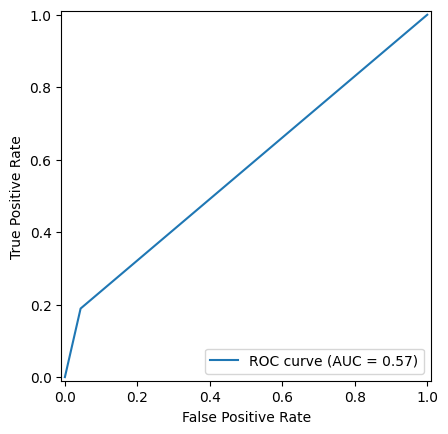

In [196]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn import metrics
LR=LogisticRegression()
LR.fit(X_train_scaled, y_train)

y_pred=LR.predict(X_test_scaled)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi :", metrics.accuracy_score(y_test, y_pred))

conf_matrix = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# SVM

              precision    recall  f1-score   support

           0       0.86      0.98      0.91      1593
           1       0.80      0.36      0.50       407

    accuracy                           0.85      2000
   macro avg       0.83      0.67      0.71      2000
weighted avg       0.85      0.85      0.83      2000

Model aniqligi: 0.8525


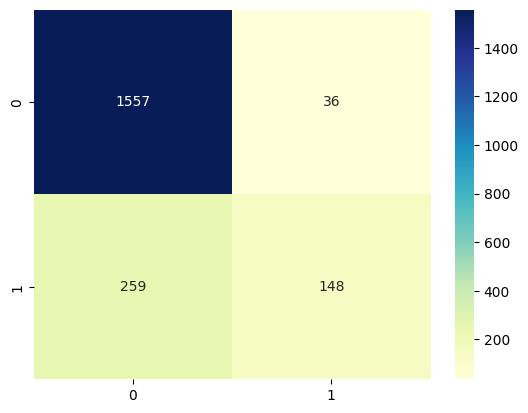

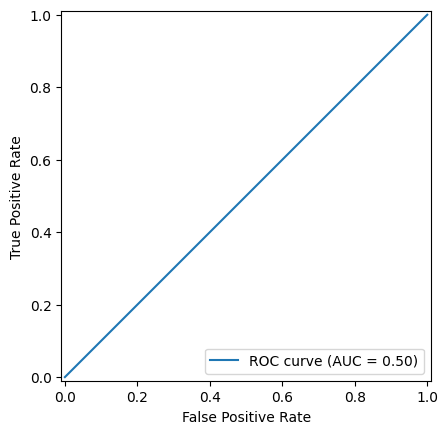

In [203]:
from sklearn.svm import SVC

# 1. Modelni yaratish (o'zgarishsiz)
svm_model = SVC(kernel='rbf', probability=True)

# 2. DIQQAT: Masshtablangan (scaled) ma'lumotlarni beramiz!
svm_model.fit(X_train_scaled, y_train)

# 3. Bashorat ham masshtablangan ma'lumotda bo'ladi
y_pred_svm = svm_model.predict(X_test_scaled)

# 4. Natijalar
print(metrics.classification_report(y_test, y_pred_svm))
print("Model aniqligi:", metrics.accuracy_score(y_test, y_pred_svm))

# Confusion matrix chizamiz
conf_mat = metrics.confusion_matrix(y_test, y_pred_svm)
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu")
plt.show()
## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

# Decision Tree

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1593
           1       0.48      0.49      0.49       407

    accuracy                           0.79      2000
   macro avg       0.68      0.68      0.68      2000
weighted avg       0.79      0.79      0.79      2000

Model aniqligi: 0.79


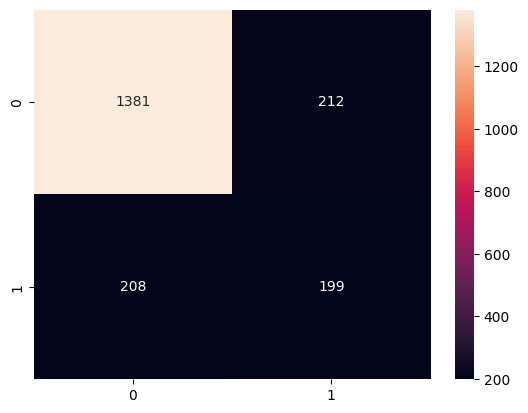

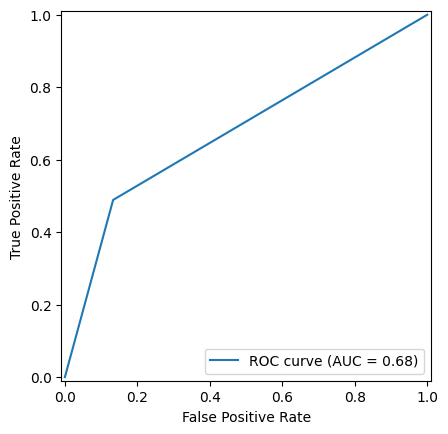

In [209]:
from sklearn.tree import DecisionTreeClassifier , plot_tree
# Modelni yaratamiz (training)
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = tree_model.predict(X_test)
print(metrics.classification_report(y_test, y_pred))
print("Model aniqligi:", metrics.accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

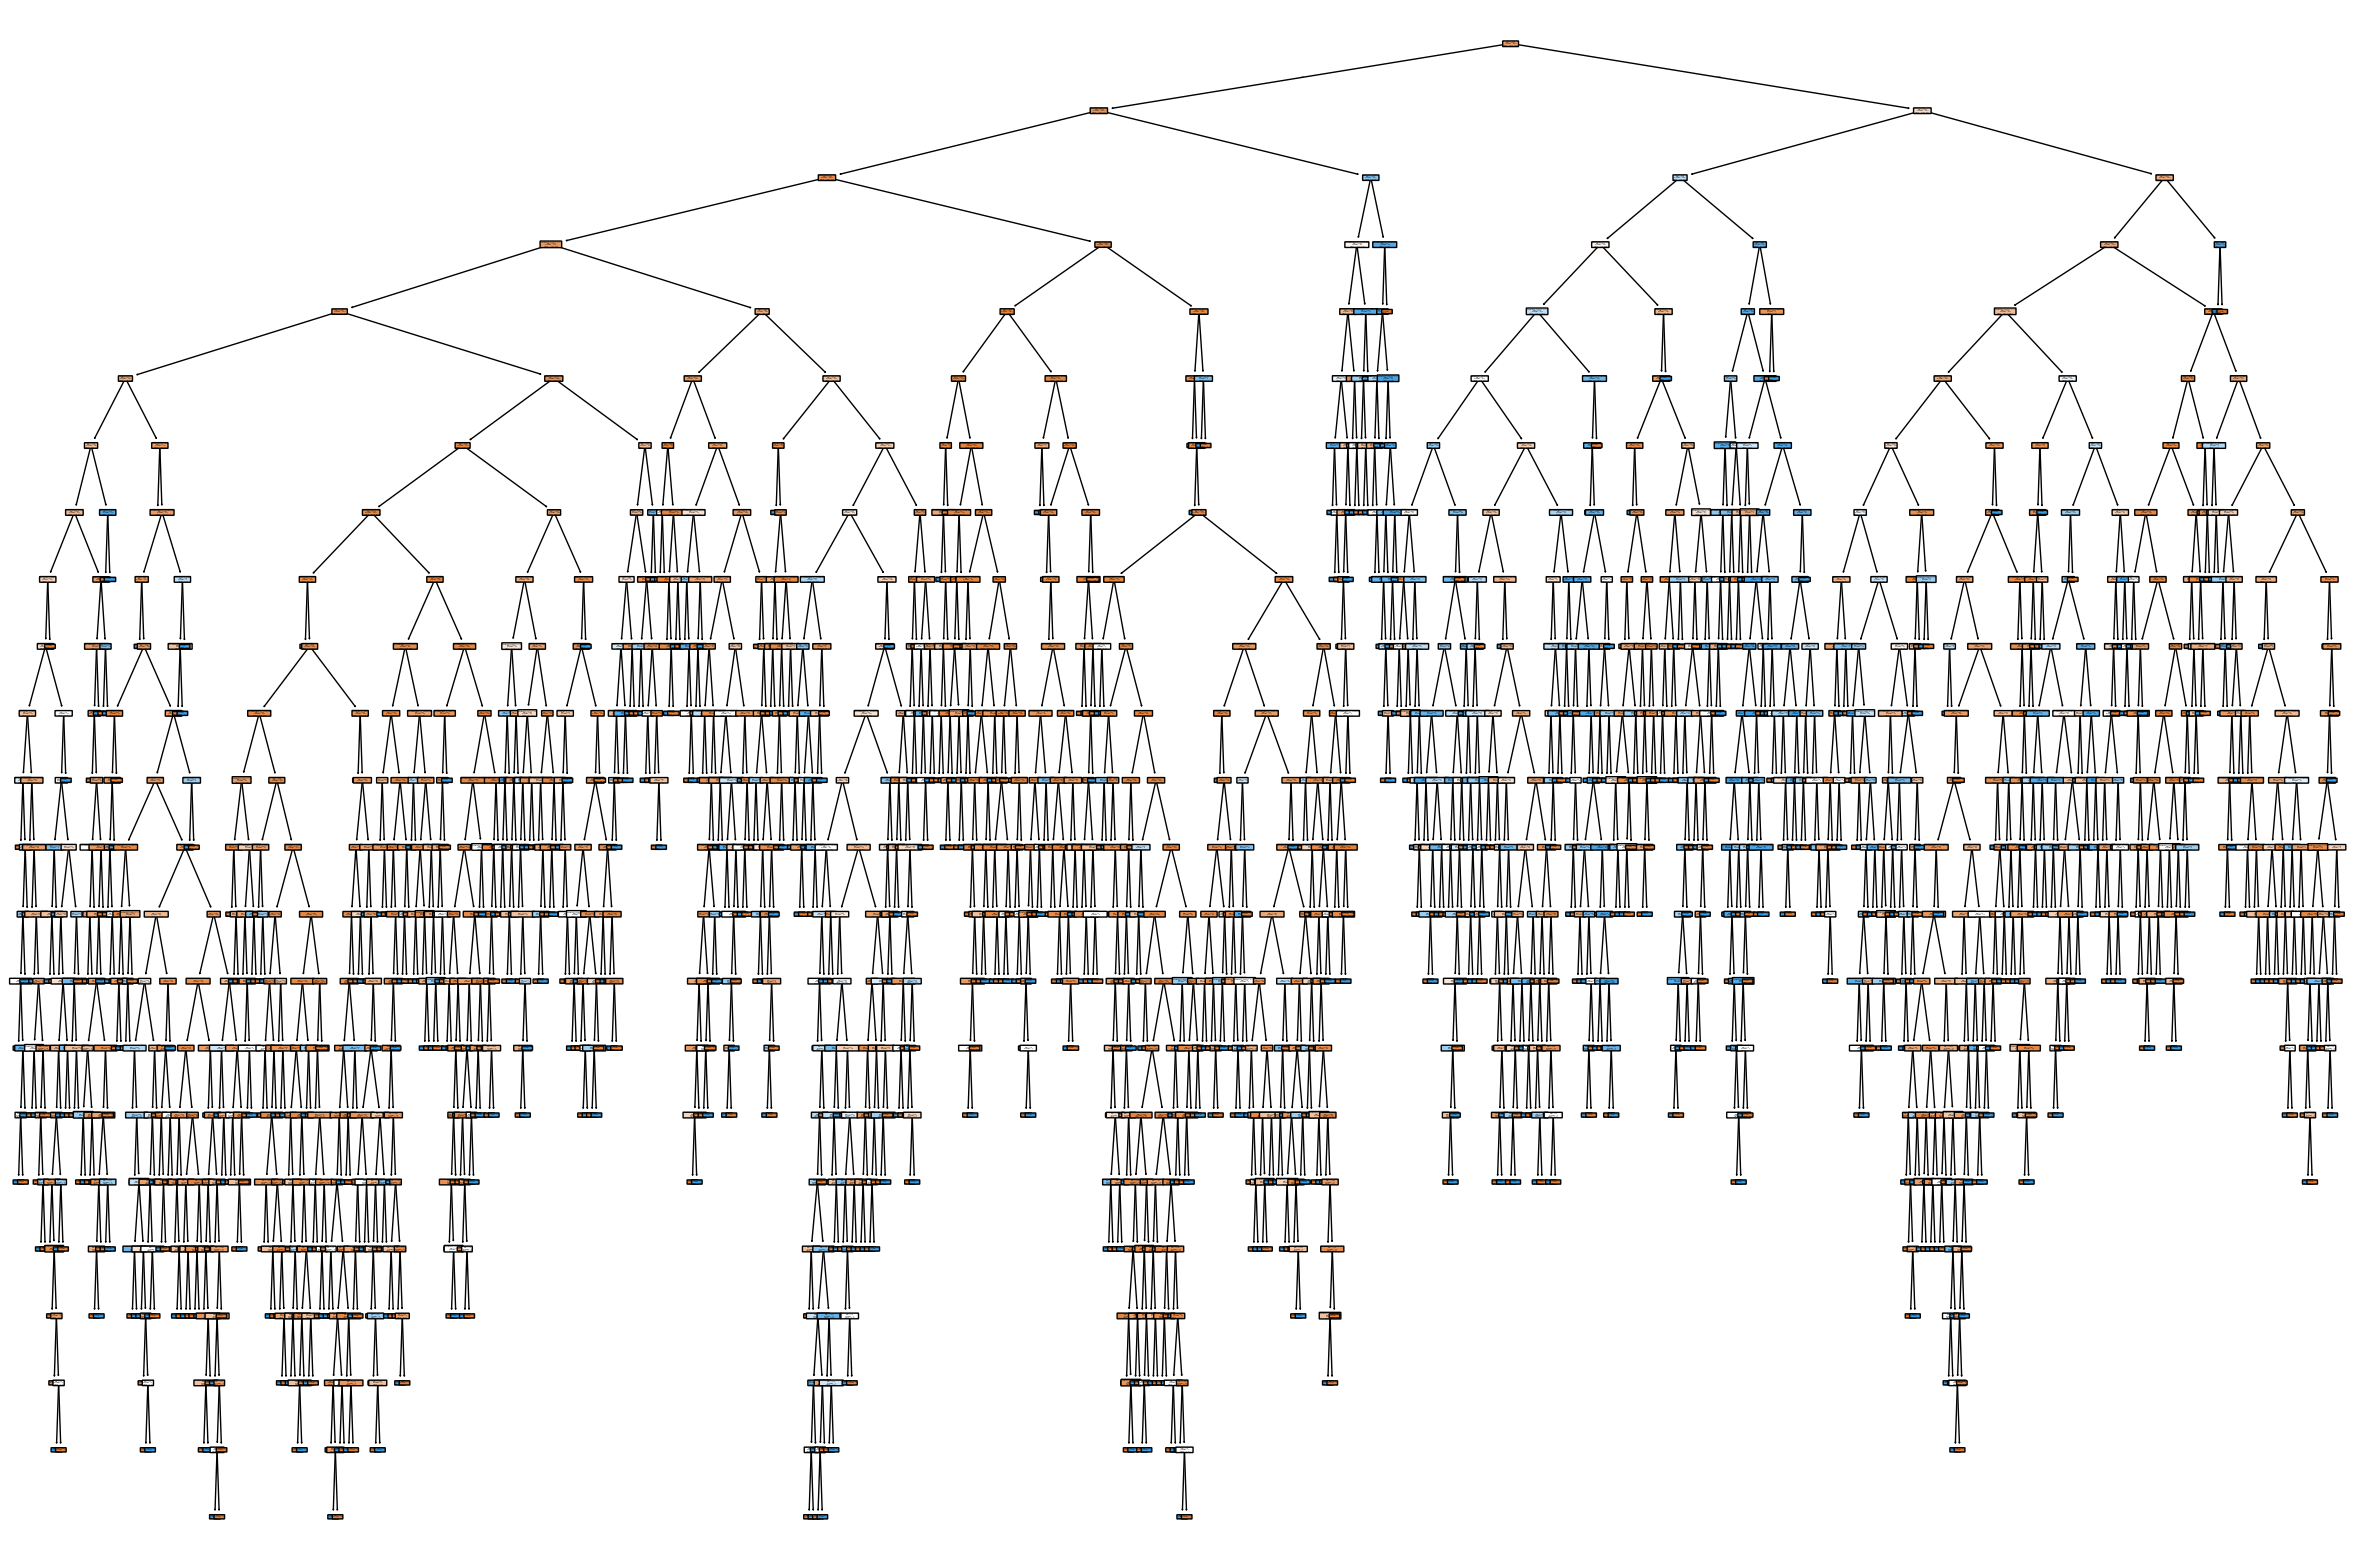

In [214]:
from sklearn.tree import plot_tree
cols = X.columns
plt.figure(figsize=(30,20))
# feature_names ga o'sha cols ni beramiz
plot_tree(tree_model, feature_names=cols, filled=True, rounded=True)
plt.show()

# Random Forest

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.68      0.48      0.56       407

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.73      2000
weighted avg       0.84      0.85      0.84      2000

Model aniqligi: 0.8475


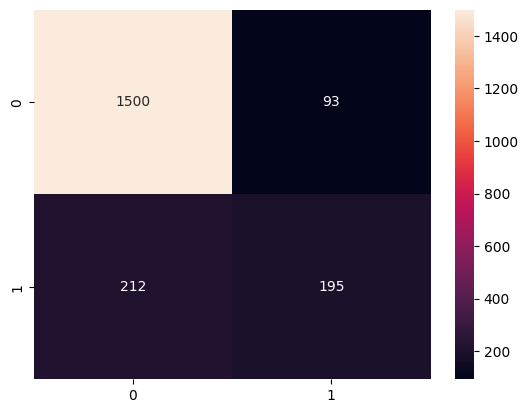

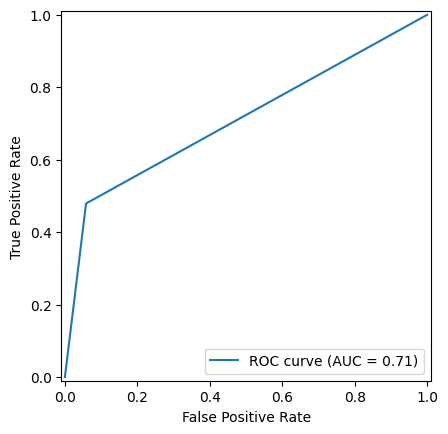

In [216]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Modelni yaratamiz (training)
RF_model = RandomForestClassifier(n_estimators=9)
RF_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = RF_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Model aniqligi:", accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1593
           1       0.66      0.49      0.57       407

    accuracy                           0.85      2000
   macro avg       0.77      0.71      0.74      2000
weighted avg       0.83      0.85      0.84      2000

Model aniqligi: 0.846


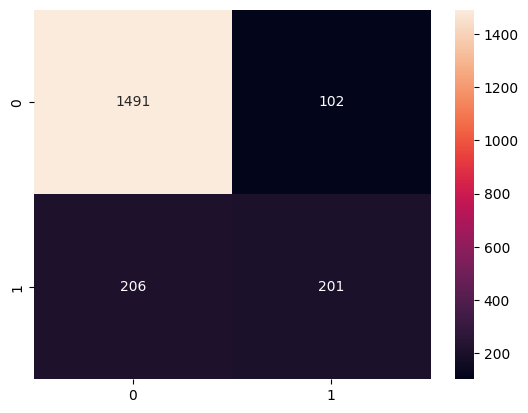

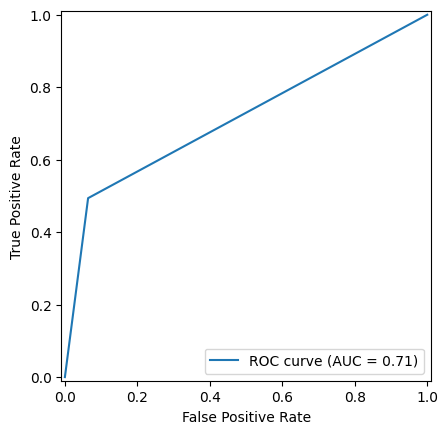

In [220]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Modelni yaratamiz (training)
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Modelni baholaymiz
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))
print("Model aniqligi:", accuracy_score(y_test,y_pred))

## confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True,fmt="g")
plt.show()

## ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='ROC curve')
display.plot()
plt.show()

Ko'rib turganimizdek eng yxashi natijani XGBoost modelimiz beryabdi .

Model ketishi mumkin bo'lgan mijozlarni bashorat qilganda ular ketmasdan oldin bonus keshbek berish kerak.
Hisobida puli bor lekin tranzaksiya qilmayotgan ishlatmayotgan mijozlarga yordam berish balkim ular Bank ilovasini tushunmayaotgandir ularni tinglab qiynalayotgan tushunmayotgan qisimlariga yordam berish yoki ilovaga o'zgartirishlar kiritish.
Faqat bir turdagi xizmatlarda foydalanadigan mijozlarga boshqa xizmatlarni taklif qilish